# Lab 4
### Contrast Enhancement

http://scikit-image.org/docs/dev/api/skimage.exposure.html#skimage.exposure.equalize_hist



In [23]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np

# Show the figures / plots inside the notebook
%matplotlib inline
from skimage.color import rgb2gray

def show_images(images,titles=None):
    #This function is used to show image(s) with titles by sending an array of images and an array of associated titles.
    # images[0] will be drawn with the title titles[0] if exists
    # You aren't required to understand this function, use it as-is.
    n_ims = len(images)
    if titles is None: titles = ['(%d)' % i for i in range(1,n_ims + 1)]
    fig = plt.figure()
    n = 1
    for image,title in zip(images,titles):
        a = fig.add_subplot(1,n_ims,n)
        if image.ndim == 2: 
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
        n += 1
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_ims)
    plt.show()

In [25]:
'''
1
Negative Transformation
'''

def negative(img):
    new_img = np.copy(img)
    for rowidx, row in enumerate(new_img):
        for i in range(len(row)):
            new_img[rowidx, i] = 255 - new_img[rowidx, i]
    return new_img


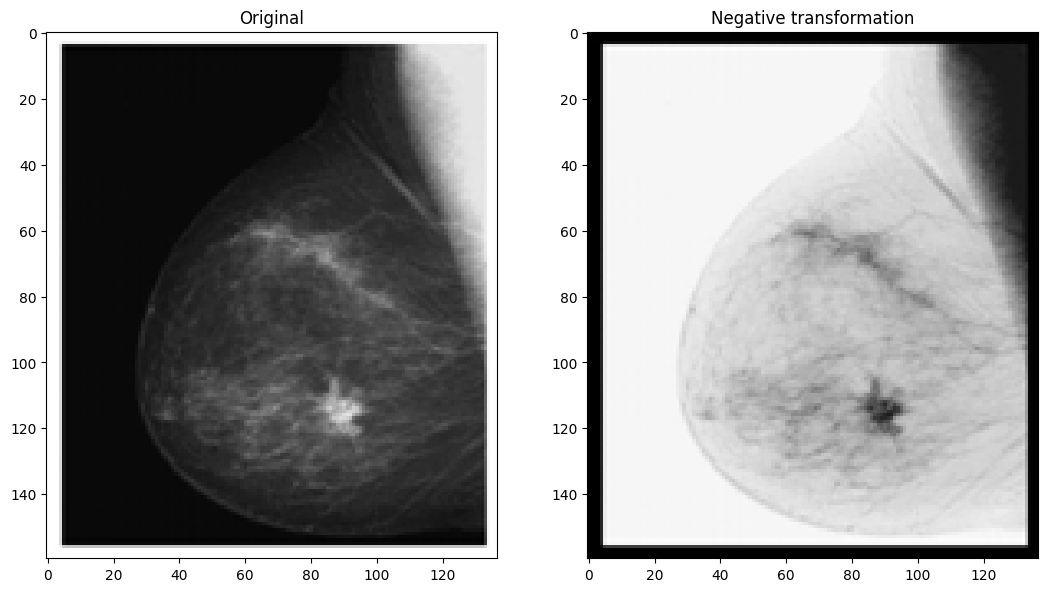

In [26]:
img = rgb2gray(io.imread('./imgs/Picture1.png')[..., :3])
img *= 255
img = img.astype(np.uint8)
neg = negative(img)
show_images([img, neg], ["Original", "Negative transformation"])

In [27]:
'''
2
Contrast Enhancement
'''

def contrast_enhancement(img):
    new_img = np.copy(img)
    for rowidx, row in enumerate(new_img):
        for i in range(len(row)):
            if 0 <= new_img[rowidx, i] <= 100:
                new_img[rowidx, i] = math.floor(1.5 * new_img[rowidx, i] + 50)
    return new_img
            

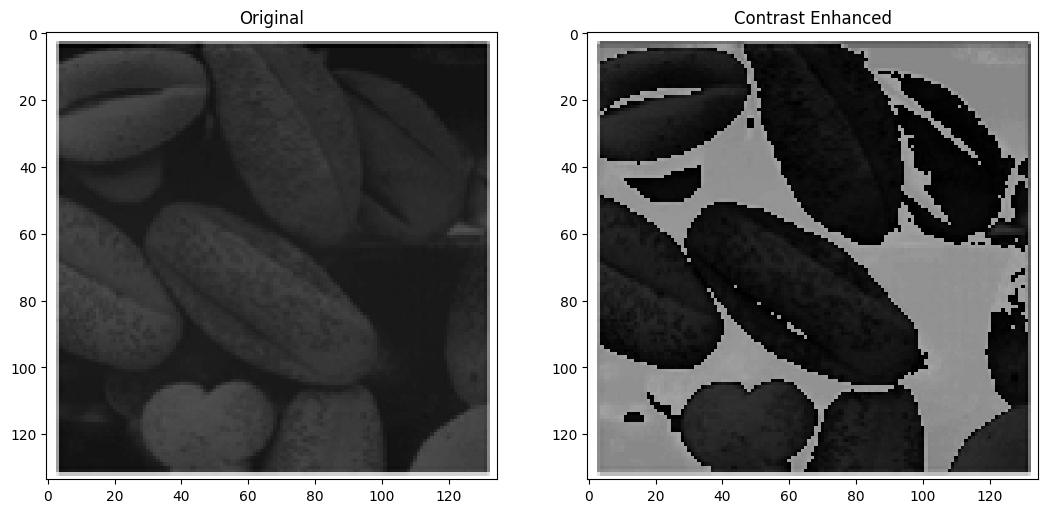

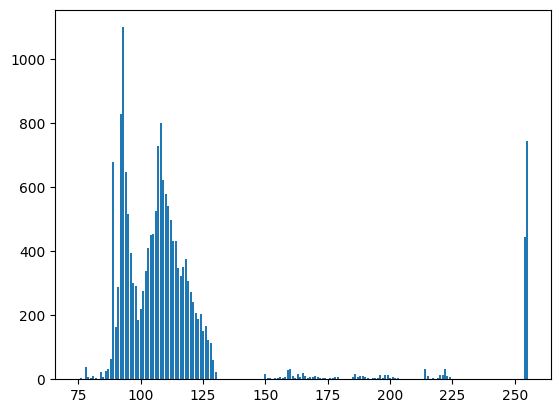

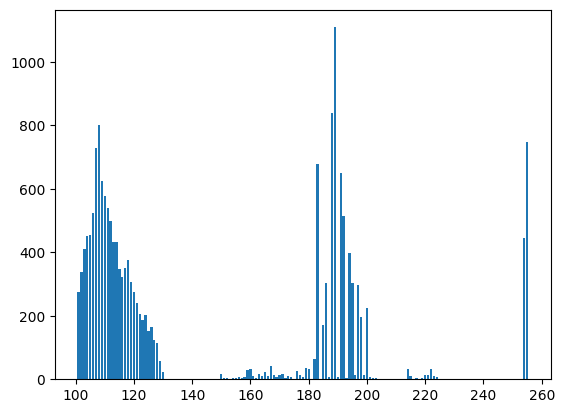

In [28]:
img = rgb2gray(io.imread('./imgs/Picture2.png')[..., :3])
img *= 255
img = img.astype(np.uint8)

contrast = contrast_enhancement(img)

show_images([img, contrast], ["Original", "Contrast Enhanced"])
showHist(img)
showHist(contrast)

In [29]:
'''
3
Gamma Correction
'''

def gamma_correction(img, c, gamma):
    new_img = np.copy(img) / 255.0
    for rowidx, row in enumerate(new_img):
        for i in range(len(row)):
            new_img[rowidx, i] = c * (new_img[rowidx, i] ** gamma)
    return (new_img * 255.0).astype(np.uint8)


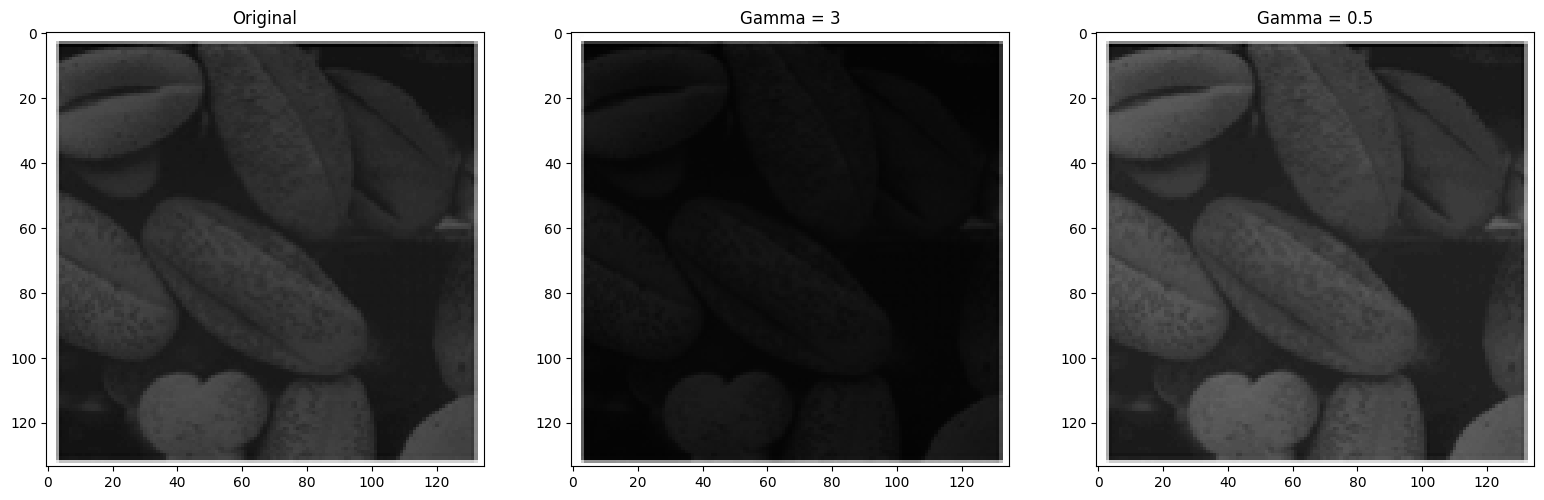

In [30]:
high_gamma = gamma_correction(img, 1, 3)
low_gamma = gamma_correction(img, 1, 0.5)

show_images([img, high_gamma, low_gamma], ["Original", "Gamma = 3", "Gamma = 0.5"])

# increasing gamma leads to a darker image. decreasing it leads to a brighter image.

In [31]:
'''
4 Histogram Eq.
Note: Histogram function of skimage returns only present intensity values not all 255
You can use showHist function from commonfunctions file
'''

def getImageWithHist(name,ext,nbins=256):
    pass


def histogram_equalization(img, G=256):
    H = np.zeros(G)
    N = img.shape[0]
    M = img.shape[1]
    new_img = np.copy(img)

    
    for rowidx, row in enumerate(img):
        for i in range(len(row)):
            img_graylevel = img[rowidx, i]
            if(img_graylevel < G):
                H[img_graylevel] += 1

    H_C = np.zeros(G)
    H_C[0] = H[0]
    for i in range(1, G):
        H_C[i] = H_C[i - 1] + H[i]

    T = np.zeros(G)
    for i in range(G):
        T[i] = round((G - 1) * H_C[i] / (M * N) )

    for rowidx, row in enumerate(img):
        for i in range(len(row)):
            img_graylevel = img[rowidx, i]
            new_img[rowidx, i] = T[img_graylevel]


    return new_img.astype(np.uint8)
    


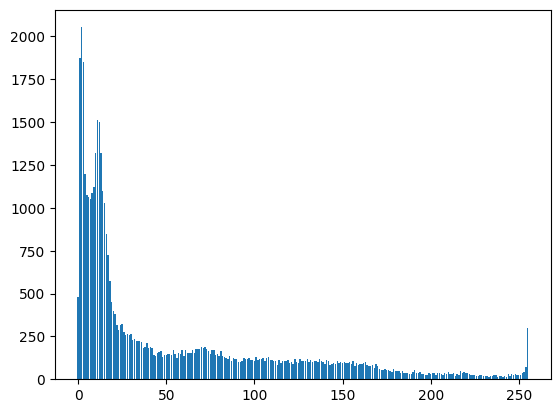

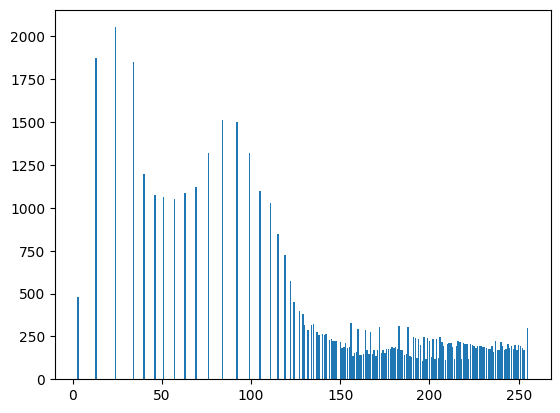

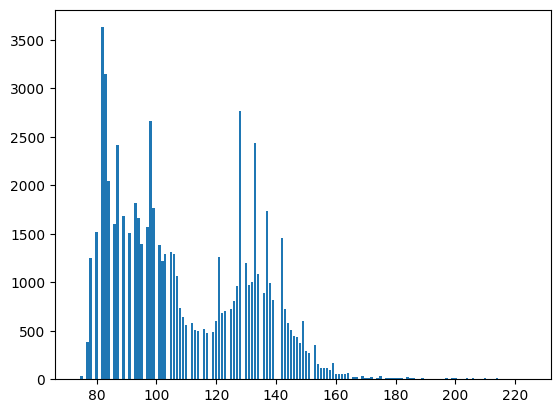

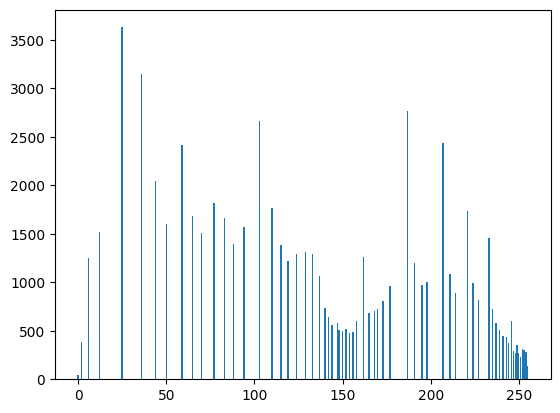

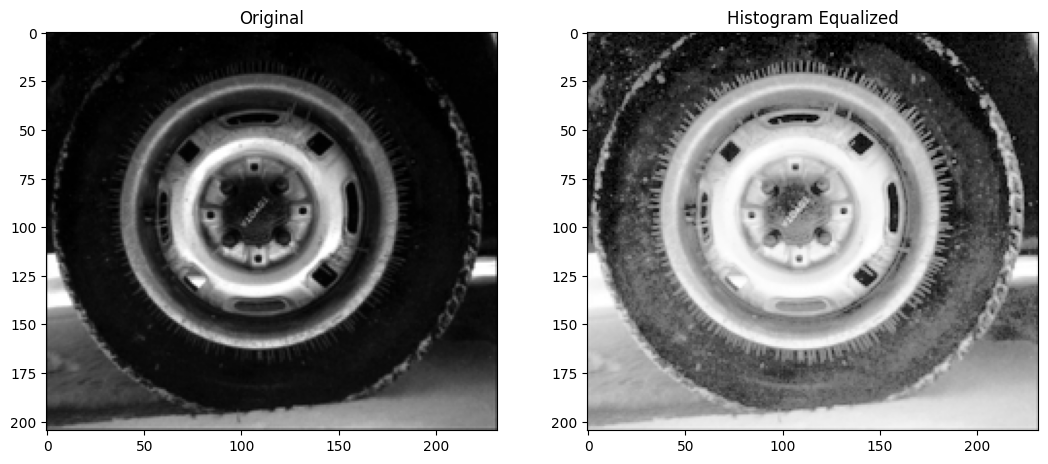

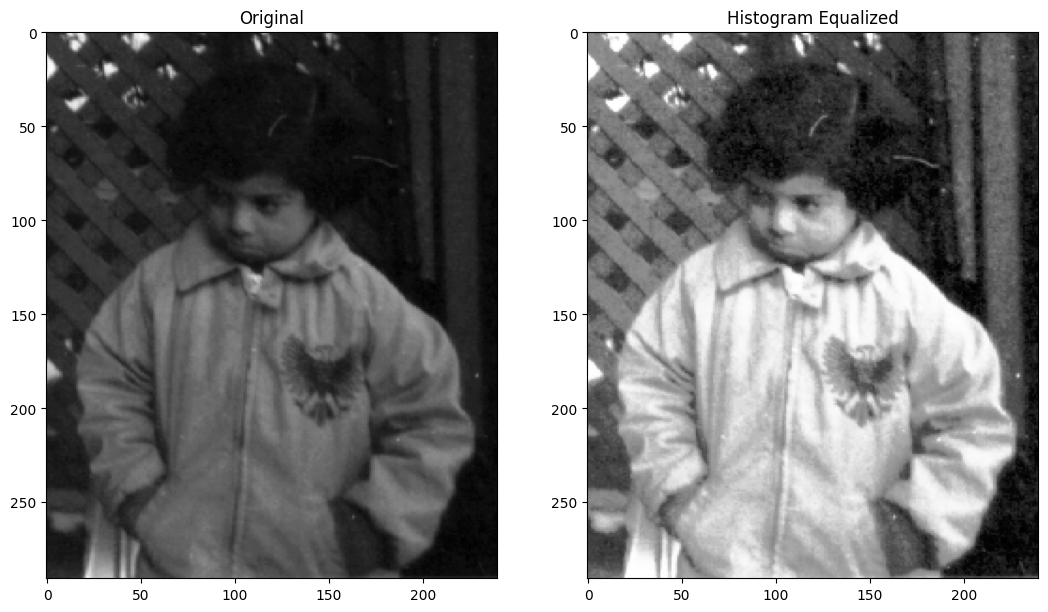

In [32]:
img = io.imread('./imgs/tire.tif')
new1_img = histogram_equalization(img)
img2 = io.imread('./imgs/pout.tif')
new2_img = histogram_equalization(img2)

showHist(img)
showHist(new1_img)

showHist(img2)
showHist(new2_img)


show_images([img, new1_img], ["Original", "Histogram Equalized"])

show_images([img2, new2_img], ["Original", "Histogram Equalized"])


